# Opdracht 1 - Database
In deze opdracht maken we verbinding met MySQL, 
maken we de tabelstructuur aan en importeren we de CSV bestanden.

In [18]:
# === IMPORTS ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine, text

print("Alle packages geladen ✓")

Alle packages geladen ✓


In [19]:
# === Verbinding met MySQL ===

# Vul hier jouw wachtwoord in dat je hebt ingesteld bij de MySQL installatie
engine = create_engine("mysql+pymysql://root:@localhost/climate_watch")

# Test de verbinding
with engine.connect() as conn:
    print("Verbinding met MySQL gelukt ✓")

Verbinding met MySQL gelukt ✓


In [20]:
# === TABELSTRUCTUUR AANMAKEN ===

with engine.connect() as conn:

    # Tabel 1: Globale temperaturen (meest algemeen)

    conn.execute(text("""
    CREATE TABLE IF NOT EXISTS global_temperatures (
                      dt DATE,
                      LandAverageTemperature FLOAT,
                      LandAverageTemperatureUncertainty FLOAT,
                      LandMaxTemperature FLOAT,
                      LandMaxTemperatureUncertainty FLOAT,
                      LandMinTemperature FLOAT,
                      LandMinTemperatureUncertainty FLOAT,
                      LandAndOceanAverageTemperature FLOAT,
                      LandAndOceanAverageTemperatureUncertainty FLOAT
                      )
    """))
    print("Tabel 1: global_temperatures is aangemaakt ✓")

    # Tabel 2: Per land

    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS temperatures_by_country (
            dt DATE,
            AverageTemperature FLOAT,
            AverageTemperatureUncertainty FLOAT,
            Country VARCHAR(100)
        )
    """))
    print("Tabel 2: temperatures_by_country aangemaakt ✓") 

    # Tabel 3: Per Staat/regio

    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS temperatures_by_state (
            dt DATE,
            AverageTemperature FLOAT,
            AverageTemperatureUncertainty FLOAT,
            State VARCHAR(100),
            Country VARCHAR(100)
        )
    """))
    print("Tabel 3: temperatures_by_state aangemaakt ✓")

    # Tabel 4: Per grote stad

    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS temperatures_by_major_city (
            dt DATE,
            AverageTemperature FLOAT,
            AverageTemperatureUncertainty FLOAT,
            City VARCHAR(100),
            Country VARCHAR(100),
            Latitude VARCHAR(10),
            Longitude VARCHAR(10)
        )
    """))
    print("Tabel 4: temperatures_by_major_city aangemaakt ✓")

    # Tabel 5: Per alle steden (meest specifiek)

    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS temperatures_by_city (
            dt DATE,
            AverageTemperature FLOAT,
            AverageTemperatureUncertainty FLOAT,
            City VARCHAR(100),
            Country VARCHAR(100),
            Latitude VARCHAR(10),
            Longitude VARCHAR(10)
        )
    """))
    print("Tabel 5: temperatures_by_city aangemaakt ✓")

    conn.commit()

print("\nAlle 5 tabellen aangemaakt ✓")



Tabel 1: global_temperatures is aangemaakt ✓
Tabel 2: temperatures_by_country aangemaakt ✓
Tabel 3: temperatures_by_state aangemaakt ✓
Tabel 4: temperatures_by_major_city aangemaakt ✓
Tabel 5: temperatures_by_city aangemaakt ✓

Alle 5 tabellen aangemaakt ✓


In [21]:
# === DATA IMPORTEREN ===

# 1. Globale temperaturen
df_global = pd.read_csv("../ClimateData/GlobalTemperatures.csv")
df_global.to_sql("global_temperatures", engine, if_exists="replace", index=False)
print(f"global_temperatures geïmporteerd ✓ ({len(df_global)} rijen)")

# 2. Per land
df_country = pd.read_csv("../ClimateData/GlobalLandTemperaturesByCountry.csv")
df_country.to_sql("temperatures_by_country", engine, if_exists="replace", index=False)
print(f"temperatures_by_country geïmporteerd ✓ ({len(df_country)} rijen)")

# 3. Per staat
df_state = pd.read_csv("../ClimateData/GlobalLandTemperaturesByState.csv")
df_state.to_sql("temperatures_by_state", engine, if_exists="replace", index=False)
print(f"temperatures_by_state geïmporteerd ✓ ({len(df_state)} rijen)")

# 4. Per grote stad
df_major_city = pd.read_csv("../ClimateData/GlobalLandTemperaturesByMajorCity.csv")
df_major_city.to_sql("temperatures_by_major_city", engine, if_exists="replace", index=False)
print(f"temperatures_by_major_city geïmporteerd ✓ ({len(df_major_city)} rijen)")

# 5. Per alle steden
df_city = pd.read_csv("../ClimateData/GlobalLandTemperaturesByCity.csv")
df_city.to_sql("temperatures_by_city", engine, if_exists="replace", index=False)
print(f"temperatures_by_city geïmporteerd ✓ ({len(df_city)} rijen)")

print("\nAlle data geïmporteerd ✓")



global_temperatures geïmporteerd ✓ (3192 rijen)
temperatures_by_country geïmporteerd ✓ (577462 rijen)
temperatures_by_state geïmporteerd ✓ (645675 rijen)
temperatures_by_major_city geïmporteerd ✓ (239177 rijen)
temperatures_by_city geïmporteerd ✓ (8599212 rijen)

Alle data geïmporteerd ✓


# Opdracht 2 - Data bekijken & subset
In dit deel maken we een subset vanaf 1980 en cleanen we de data.


In [22]:
# === Stap 3: Data ophalen (subset vanaf 1980) ===

df_global = pd.read_sql("SELECT * FROM global_temperatures WHERE dt >= '1980-01-01'", engine)
print(f"Global temperatures vanaf 1980 opgehaald ✓: {len(df_global)} rijen")

df_country = pd.read_sql("SELECT * FROM temperatures_by_country WHERE dt >= '1980-01-01'", engine)
print(f"Temperatures by country vanaf 1980 opgehaald ✓: {len(df_country)} rijen")

df_state = pd.read_sql("SELECT * FROM temperatures_by_state WHERE dt >= '1980-01-01'", engine)
print(f"Temperatures by state vanaf 1980 opgehaald ✓: {len(df_state)} rijen")

df_major_city = pd.read_sql("SELECT * FROM temperatures_by_major_city WHERE dt >= '1980-01-01'", engine)
print(f"Temperatures by major city vanaf 1980 opgehaald ✓: {len(df_major_city)} rijen")

df_city = pd.read_sql("SELECT * FROM temperatures_by_city WHERE dt >= '1980-01-01'", engine)
print(f"Temperatures by city vanaf 1980 opgehaald ✓: {len(df_city)} rijen")

print("Data vanaf 1980 opgehaald ✓")    

Global temperatures vanaf 1980 opgehaald ✓: 432 rijen
Temperatures by country vanaf 1980 opgehaald ✓: 98415 rijen
Temperatures by state vanaf 1980 opgehaald ✓: 97605 rijen
Temperatures by major city vanaf 1980 opgehaald ✓: 40500 rijen
Temperatures by city vanaf 1980 opgehaald ✓: 1421550 rijen
Data vanaf 1980 opgehaald ✓


In [23]:
# === Stap 4: Data bekijken ===

# Bekijk de eerste paar rijen, hoe veel rijen en kolommen en de datatypes van de kolommen van elke dataframe. Welke verschillen zie je tussen de tabellen? Welke overeenkomsten?

print("=== Global Temperatures ===")
print(df_global.head())
print(df_global.info())
print(f"Shape: {df_global.shape}")


=== Global Temperatures ===
           dt  LandAverageTemperature  LandAverageTemperatureUncertainty  \
0  1980-01-01                   2.956                              0.087   
1  1980-02-01                   3.652                              0.099   
2  1980-03-01                   5.367                              0.103   
3  1980-04-01                   8.935                              0.106   
4  1980-05-01                  11.770                              0.089   

   LandMaxTemperature  LandMaxTemperatureUncertainty  LandMinTemperature  \
0               8.468                          0.080              -2.457   
1               9.260                          0.129              -1.864   
2              11.240                          0.160              -0.379   
3              14.821                          0.129               3.109   
4              17.713                          0.234               6.131   

   LandMinTemperatureUncertainty  LandAndOceanAverageTempe

In [24]:
# === Temperatures by Country ===
print("\n=== Temperatures by Country ===")
print(df_country.head())
print(df_country.info())
print(f"Shape: {df_country.shape}")



=== Temperatures by Country ===
           dt  AverageTemperature  AverageTemperatureUncertainty Country
0  1980-01-01              -4.073                          0.518   Åland
1  1980-02-01              -6.484                          0.441   Åland
2  1980-03-01              -3.947                          0.466   Åland
3  1980-04-01               2.928                          0.597   Åland
4  1980-05-01               6.154                          0.241   Åland
<class 'pandas.DataFrame'>
RangeIndex: 98415 entries, 0 to 98414
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   dt                             98415 non-null  str    
 1   AverageTemperature             97789 non-null  float64
 2   AverageTemperatureUncertainty  98193 non-null  float64
 3   Country                        98415 non-null  str    
dtypes: float64(2), str(2)
memory usage: 3.0 MB
None
Shape: (98415, 4)


In [25]:
# === Temperatures by Major City ===
print("\n=== Temperatures by State ===")
print(df_state.head())
print(df_state.info())
print(f"Shape: {df_state.shape}")


=== Temperatures by State ===
           dt  AverageTemperature  AverageTemperatureUncertainty State Country
0  1980-01-01              26.652                          0.190  Acre  Brazil
1  1980-02-01              26.495                          0.495  Acre  Brazil
2  1980-03-01              26.270                          0.236  Acre  Brazil
3  1980-04-01              26.430                          0.201  Acre  Brazil
4  1980-05-01              25.802                          0.882  Acre  Brazil
<class 'pandas.DataFrame'>
RangeIndex: 97605 entries, 0 to 97604
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   dt                             97605 non-null  str    
 1   AverageTemperature             97424 non-null  float64
 2   AverageTemperatureUncertainty  97424 non-null  float64
 3   State                          97605 non-null  str    
 4   Country                        97

In [26]:
# === Temperatures by Major City ===
print("\n=== Temperatures by Major City ===")
print(df_major_city.head())
print(df_major_city.info())
print(f"Shape: {df_major_city.shape}")


=== Temperatures by Major City ===
           dt  AverageTemperature  AverageTemperatureUncertainty     City  \
0  1980-01-01              27.409                          0.497  Abidjan   
1  1980-02-01              28.192                          0.358  Abidjan   
2  1980-03-01              28.303                          0.430  Abidjan   
3  1980-04-01              28.284                          0.223  Abidjan   
4  1980-05-01              26.709                          0.383  Abidjan   

         Country Latitude Longitude  
0  Côte D'Ivoire    5.63N     3.23W  
1  Côte D'Ivoire    5.63N     3.23W  
2  Côte D'Ivoire    5.63N     3.23W  
3  Côte D'Ivoire    5.63N     3.23W  
4  Côte D'Ivoire    5.63N     3.23W  
<class 'pandas.DataFrame'>
RangeIndex: 40500 entries, 0 to 40499
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   dt                             40500 non-null  str 

In [27]:
# === Temperatures by City ===
print("\n=== Temperatures by City ===")
print(df_city.head())
print(df_city.info())
print(f"Shape: {df_city.shape}")


=== Temperatures by City ===
           dt  AverageTemperature  AverageTemperatureUncertainty   City  \
0  1980-01-01              -1.850                          0.363  Århus   
1  1980-02-01              -2.171                          0.377  Århus   
2  1980-03-01               0.625                          0.178  Århus   
3  1980-04-01               6.151                          0.203  Århus   
4  1980-05-01              11.434                          0.226  Århus   

   Country Latitude Longitude  
0  Denmark   57.05N    10.33E  
1  Denmark   57.05N    10.33E  
2  Denmark   57.05N    10.33E  
3  Denmark   57.05N    10.33E  
4  Denmark   57.05N    10.33E  
<class 'pandas.DataFrame'>
RangeIndex: 1421550 entries, 0 to 1421549
Data columns (total 7 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   dt                             1421550 non-null  str    
 1   AverageTemperature             1418

# Opdracht 3 - Data Cleaning
In dit deel gaan we de data opschonen.


In [28]:
# === STAP 5.1: CHECK ONTBREKENDE WAARDEN ===

# Global Temperatures
print("=== GLOBAL TEMPERATURES ===")
print("Ontbrekende waarden per kolom:")
print(df_global.isnull().sum())
print(f"Rijen met minstens 1 ontbrekende waarde: {df_global.isnull().any(axis=1).sum()}")

# Per Land
print("\n=== PER LAND ===")
print("Ontbrekende waarden per kolom:")
print(df_country.isnull().sum())
print(f"Rijen met minstens 1 ontbrekende waarde: {df_country.isnull().any(axis=1).sum()}")

# Per Staat
print("\n=== PER STAAT ===")
print("Ontbrekende waarden per kolom:")
print(df_state.isnull().sum())
print(f"Rijen met minstens 1 ontbrekende waarde: {df_state.isnull().any(axis=1).sum()}")

# Per Grote Stad
print("\n=== PER GROTE STAD ===")
print("Ontbrekende waarden per kolom:")
print(df_major_city.isnull().sum())
print(f"Rijen met minstens 1 ontbrekende waarde: {df_major_city.isnull().any(axis=1).sum()}")

# Per Alle Steden
print("\n=== PER ALLE STEDEN ===")
print("Ontbrekende waarden per kolom:")
print(df_city.isnull().sum())
print(f"Rijen met minstens 1 ontbrekende waarde: {df_city.isnull().any(axis=1).sum()}")

=== GLOBAL TEMPERATURES ===
Ontbrekende waarden per kolom:
dt                                           0
LandAverageTemperature                       0
LandAverageTemperatureUncertainty            0
LandMaxTemperature                           0
LandMaxTemperatureUncertainty                0
LandMinTemperature                           0
LandMinTemperatureUncertainty                0
LandAndOceanAverageTemperature               0
LandAndOceanAverageTemperatureUncertainty    0
dtype: int64
Rijen met minstens 1 ontbrekende waarde: 0

=== PER LAND ===
Ontbrekende waarden per kolom:
dt                                 0
AverageTemperature               626
AverageTemperatureUncertainty    222
Country                            0
dtype: int64
Rijen met minstens 1 ontbrekende waarde: 626

=== PER STAAT ===
Ontbrekende waarden per kolom:
dt                                 0
AverageTemperature               181
AverageTemperatureUncertainty    181
State                              0
Country  

In [29]:
# === STAP 5.2: VERGELIJKING CLEANING OPTIES ===

tabellen = {
    "Global Temperatures": (df_global, "LandAverageTemperature"),
    "Per Land": (df_country, "AverageTemperature"),
    "Per Staat": (df_state, "AverageTemperature"),
    "Per Grote Stad": (df_major_city, "AverageTemperature"),
    "Per Alle Steden": (df_city, "AverageTemperature")
}

for naam, (df, kolom) in tabellen.items():
    print(f"\n=== {naam} ===")
    
    # Gemiddelde VOOR cleaning
    gemiddelde_voor = df[kolom].mean()
    print(f"Gemiddelde VOOR cleaning:          {gemiddelde_voor:.2f} graden")
    
    # Optie 1: Verwijderen
    df_verwijderd = df.dropna()
    gemiddelde_verwijderd = df_verwijderd[kolom].mean()
    print(f"Gemiddelde NA verwijderen:                    {gemiddelde_verwijderd:.2f} graden (verschil: {abs(gemiddelde_voor - gemiddelde_verwijderd):.2f})")
    
    # Optie 2: Invullen met 0
    df_nul = df.fillna(0)
    gemiddelde_nul = df_nul[kolom].mean()
    print(f"Gemiddelde NA invullen met 0:                 {gemiddelde_nul:.2f} graden (verschil: {abs(gemiddelde_voor - gemiddelde_nul):.2f})")
    
    # Optie 3: Invullen met gemiddelde
    df_gemiddelde = df.fillna(df.mean(numeric_only=True))
    gemiddelde_gem = df_gemiddelde[kolom].mean()
    print(f"Gemiddelde NA invullen met gemiddelde:        {gemiddelde_gem:.2f} graden (verschil: {abs(gemiddelde_voor - gemiddelde_gem):.2f})")
    
    # Rijen vergelijking
    print(f"Rijen over na verwijderen:         {len(df_verwijderd)} van {len(df)}")


=== Global Temperatures ===
Gemiddelde VOOR cleaning:          9.26 graden
Gemiddelde NA verwijderen:                    9.26 graden (verschil: 0.00)
Gemiddelde NA invullen met 0:                 9.26 graden (verschil: 0.00)
Gemiddelde NA invullen met gemiddelde:        9.26 graden (verschil: 0.00)
Rijen over na verwijderen:         432 van 432

=== Per Land ===
Gemiddelde VOOR cleaning:          19.24 graden
Gemiddelde NA verwijderen:                    19.24 graden (verschil: 0.00)
Gemiddelde NA invullen met 0:                 19.12 graden (verschil: 0.12)
Gemiddelde NA invullen met gemiddelde:        19.24 graden (verschil: 0.00)
Rijen over na verwijderen:         97789 van 98415

=== Per Staat ===
Gemiddelde VOOR cleaning:          10.33 graden
Gemiddelde NA verwijderen:                    10.33 graden (verschil: 0.00)
Gemiddelde NA invullen met 0:                 10.31 graden (verschil: 0.02)
Gemiddelde NA invullen met gemiddelde:        10.33 graden (verschil: 0.00)
Rijen over n

### 5.3 Cleaning toepassen
We vullen alle ontbrekende waarden in met het gemiddelde van die kolom. Voordat we dit doen daan we eerst de datum omzetten naar een datum waarmee we kunnen werken en de spaties weghalen bij de tekst data. 


In [30]:
# === Stap 5.3 CLEANING FUNCTIE ===

def clean_dataframe(df, fillna=True):
    
    # Datum omzetten
    df["dt"] = pd.to_datetime(df["dt"])
    
    # Spaties weghalen bij tekst kolommen
    for kolom in df.select_dtypes(include=['str']).columns:
        if 'Temperature' not in kolom and kolom != 'dt':
            df[kolom] = df[kolom].str.strip()
    
    # Temperaturen naar numeriek
    for kolom in df.select_dtypes(include=['str']).columns:
        if 'Temperature' in kolom:
            df[kolom] = pd.to_numeric(df[kolom], errors='coerce')
    
    # Ontbrekende waarden invullen
    if fillna:
        for kolom in df.select_dtypes(include='number').columns:
            if 'Ocean' in kolom:
                # LandAndOcean: vóór 1850 NaN laten, ná 1850 invullen met gemiddelde
                gemiddelde = df.loc[df["dt"] >= "1850-01-01", kolom].mean()
                mask = df[kolom].isna() & (df["dt"] >= "1850-01-01")
                df.loc[mask, kolom] = gemiddelde
                df.loc[df["dt"] < "1850-01-01", kolom] = None  # forceer NaN vóór 1850
            else:
                # Alle andere kolommen: gewoon invullen met gemiddelde
                df[kolom] = df[kolom].fillna(df[kolom].mean())
    
    # Afronden
    df = df.round(3)
    
    return df

# === CLEANING TOEPASSEN ===
df_global = clean_dataframe(df_global)
df_country = clean_dataframe(df_country)
df_state = clean_dataframe(df_state)
df_major_city = clean_dataframe(df_major_city)
df_city = clean_dataframe(df_city)

# Verificatie
print("Ontbrekende waarden na cleaning:")
print(f"Global:          {df_global.isnull().sum().sum()}")
print(f"Per land:        {df_country.isnull().sum().sum()}")
print(f"Per staat:       {df_state.isnull().sum().sum()}")
print(f"Per grote stad:  {df_major_city.isnull().sum().sum()}")
print(f"Alle steden:     {df_city.isnull().sum().sum()}")

print("\nCleaning klaar ✓")

C:\Users\Nesta\AppData\Local\Temp\ipykernel_30480\2275454090.py:32: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df = df.round(3)
C:\Users\Nesta\AppData\Local\Temp\ipykernel_30480\2275454090.py:32: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df = df.round(3)
C:\Users\Nesta\AppData\Local\Temp\ipykernel_30480\2275454090.py:32: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df = df.round(3)
C:\Users\Nesta\AppData\Local\Temp\ipykernel_30480\2275454090.py:32: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df = df.round(3)
C:\Users\Nesta\AppData\Local\Temp\ipykernel_30480\2275454090.py:32: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df = df.round(3)


Ontbrekende waarden na cleaning:
Global:          0
Per land:        0
Per staat:       0
Per grote stad:  0
Alle steden:     0

Cleaning klaar ✓


# Opdracht 4: opdrachten
## Opdracht 4.1 Exploration
In dit deel verkennen we de data met statistieken en visualisaties.


In [31]:
# === Stap 6.1: Algemene statistieken ===


print("=== Global Temperatures ===")
print(df_global.describe())

print("\n=== Per Land ===")
print(df_country.describe())

print("\n=== Per Staat ===")
print(df_state.describe())

print("\n=== Per Grote Stad ===")
print(df_major_city.describe())

print("\n=== Per Alle Steden ===")
print(df_city.describe())

=== Global Temperatures ===
                        dt  LandAverageTemperature  \
count                  432              432.000000   
mean   1997-12-15 23:00:00                9.259451   
min    1980-01-01 00:00:00                2.558000   
25%    1988-12-24 06:00:00                5.217000   
50%    1997-12-16 12:00:00                9.480500   
75%    2006-12-08 18:00:00               13.224000   
max    2015-12-01 00:00:00               15.482000   
std                    NaN                4.138503   

       LandAverageTemperatureUncertainty  LandMaxTemperature  \
count                         432.000000          432.000000   
mean                            0.084926           14.964331   
min                             0.034000            8.090000   
25%                             0.067000           10.710500   
50%                             0.083000           15.207500   
75%                             0.098000           19.076250   
max                             0.221

In [32]:
# === Stap 6.2: Distributie over de jaren  === 

# Jaar kolom aanmaken global temperatures
df_global["jaar"] = df_global["dt"].dt.year

# Gemiddelde temperatuur per jaar
per_jaar = df_global.groupby("jaar")["LandAverageTemperature"].mean()

print("Gemiddelde temperatuur per jaar:")
print(per_jaar)



Gemiddelde temperatuur per jaar:
jaar
1980    8.980333
1981    9.165833
1982    8.639167
1983    9.028167
1984    8.691833
1985    8.658000
1986    8.833583
1987    8.994417
1988    9.201583
1989    8.922000
1990    9.234167
1991    9.179417
1992    8.836583
1993    8.866583
1994    9.038750
1995    9.347083
1996    9.038917
1997    9.202583
1998    9.522667
1999    9.285083
2000    9.201167
2001    9.414583
2002    9.570417
2003    9.525583
2004    9.324583
2005    9.700917
2006    9.532500
2007    9.732167
2008    9.431750
2009    9.505250
2010    9.703083
2011    9.516000
2012    9.507333
2013    9.606500
2014    9.570667
2015    9.831000
Name: LandAverageTemperature, dtype: float64


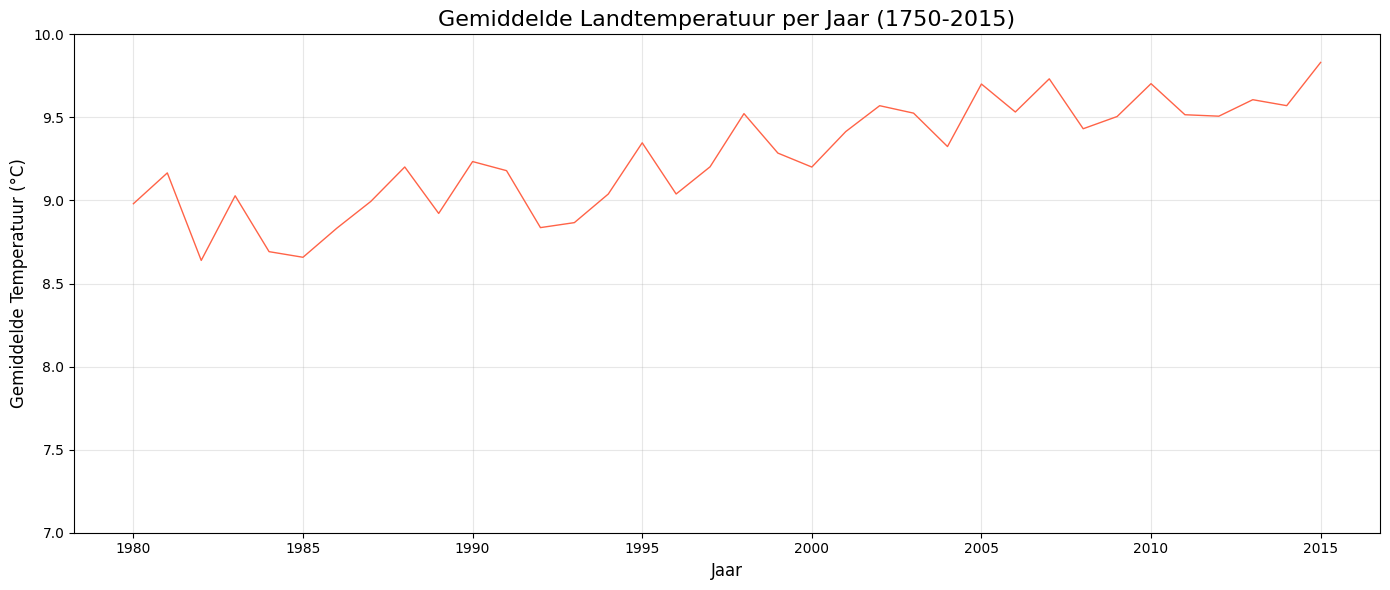

In [33]:
# === STAP 6.3: VISUALISATIE DISTRIBUTIE OVER DE JAREN ===

# Jaar kolom aanmaken
df_global["dt"] = pd.to_datetime(df_global["dt"])
df_global["jaar"] = df_global["dt"].dt.year

# Bereken opnieuw specifiek voor df_global
per_jaar_global = df_global.groupby("jaar")["LandAverageTemperature"].mean()

plt.figure(figsize=(14, 6))
plt.plot(per_jaar_global.index, per_jaar_global.values, color="tomato", linewidth=1)
plt.title("Gemiddelde Landtemperatuur per Jaar (1750-2015)", fontsize=16)
plt.xlabel("Jaar", fontsize=12)
plt.ylabel("Gemiddelde Temperatuur (°C)", fontsize=12)
plt.ylim(7, 10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Opdracht 4.2 - Gerichte Dataset
### Country Dataset 

In [34]:
# === COUNTRY DATASET: GEMIDDELDE TEMPERATUUR PER LAND ===

# Gemiddelde temperatuur per land berekenen
gem_per_land = df_country.groupby("Country")["AverageTemperature"].mean()

print("Gemiddelde temperatuur per land:")
print(gem_per_land)

Gemiddelde temperatuur per land:
Country
Afghanistan       14.974437
Africa            24.677415
Albania           13.248526
Algeria           23.859449
American Samoa    27.088301
                    ...    
Western Sahara    23.172422
Yemen             26.818760
Zambia            21.847504
Zimbabwe          21.689346
Åland              6.181830
Name: AverageTemperature, Length: 243, dtype: float64


In [35]:
# === TOP 10 WARMSTE EN KOUDSTE LANDEN ===

# Top 10 warmste landen
top10_warmst = gem_per_land.nlargest(10)
print("=== Top 10 warmste landen ===")
print(top10_warmst)

# Top 10 koudste landen
top10_koudst = gem_per_land.nsmallest(10)
print("\n=== Top 10 koudste landen ===")
print(top10_koudst)


=== Top 10 warmste landen ===
Country
Djibouti                29.361617
Mali                    29.079235
Burkina Faso            28.666185
Senegal                 28.610928
Aruba                   28.508240
United Arab Emirates    28.455714
Mauritania              28.341822
Gambia                  28.183909
Niger                   28.033672
Curaçao                 27.948425
Name: AverageTemperature, dtype: float64

=== Top 10 koudste landen ===
Country
Greenland                                   -17.720198
Denmark                                     -17.187822
Svalbard And Jan Mayen                       -6.521674
Russia                                       -4.338299
Canada                                       -4.019440
Mongolia                                      0.390798
Norway                                        0.969649
South Georgia And The South Sandwich Isla     1.998499
Iceland                                       2.070768
Finland                                       2

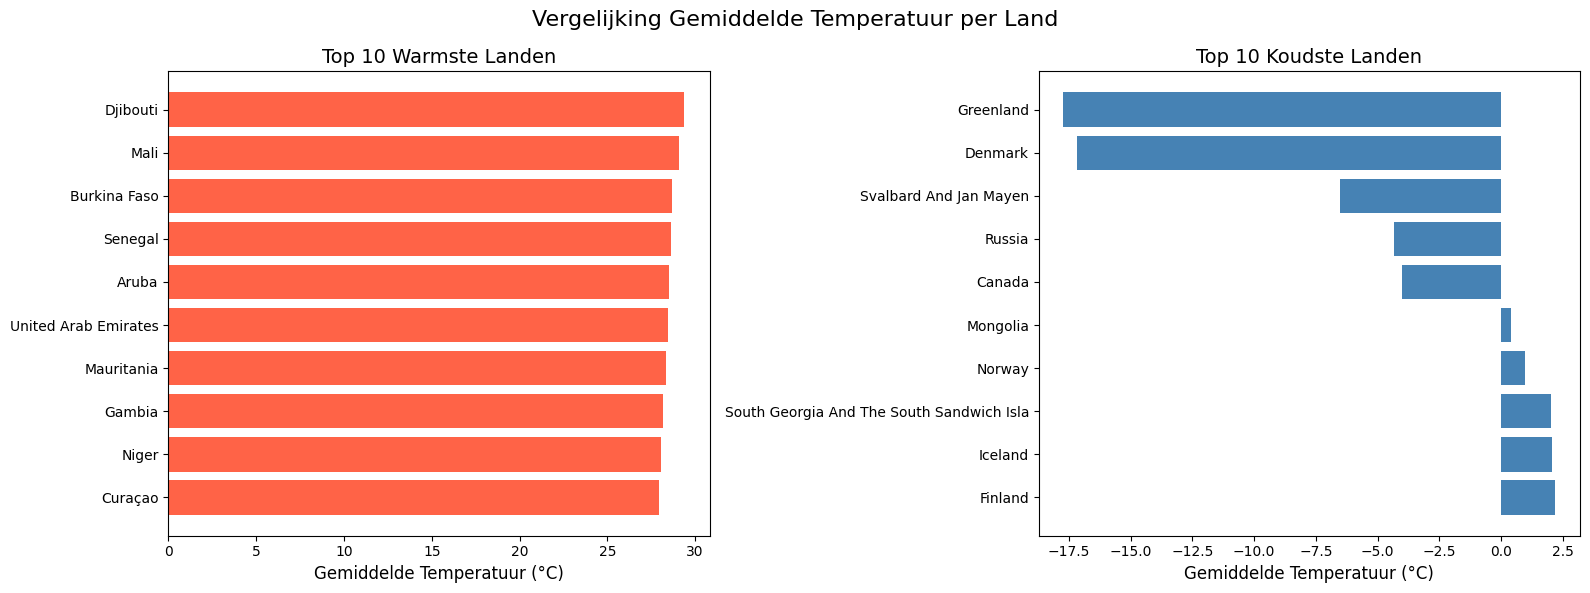

In [36]:
# === VISUALISATIE TOP 10 WARMSTE EN KOUDSTE LANDEN ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 warmste landen
ax1.barh(top10_warmst.index, top10_warmst.values, color="tomato")
ax1.set_title("Top 10 Warmste Landen", fontsize=14)
ax1.set_xlabel("Gemiddelde Temperatuur (°C)", fontsize=12)
ax1.invert_yaxis()

# Top 10 koudste landen
ax2.barh(top10_koudst.index, top10_koudst.values, color="steelblue")
ax2.set_title("Top 10 Koudste Landen", fontsize=14)
ax2.set_xlabel("Gemiddelde Temperatuur (°C)", fontsize=12)
ax2.invert_yaxis()

plt.suptitle("Vergelijking Gemiddelde Temperatuur per Land", fontsize=16)
plt.tight_layout()
plt.show()

### Major City Dataset


In [37]:
# === MAJOR CITY: GEMIDDELDE TEMPERATUUR PER STAD ===

# Gemiddelde temperatuur per stad
gem_per_stad = df_major_city.groupby("City")["AverageTemperature"].mean()

print("Gemiddelde temperatuur per stad:")
print(gem_per_stad)

Gemiddelde temperatuur per stad:
City
Abidjan        26.737867
Addis Abeba    18.072081
Ahmadabad      27.165430
Aleppo         18.081388
Alexandria     20.935044
                 ...    
Tokyo          13.167328
Toronto         6.807879
Umm Durman     29.627148
Wuhan          17.370580
Xian           12.083301
Name: AverageTemperature, Length: 100, dtype: float64


In [38]:
# === STEDEN MET GROOTSTE TEMPERATUURVERSCHIL ===

# Verschil tussen max en min temperatuur per stad
verschil_per_stad = df_major_city.groupby("City")["AverageTemperature"].agg(
    lambda x: x.max() - x.min()
)

# Top 10 steden met grootste verschil
top10_verschil = verschil_per_stad.nlargest(10)

print("Top 10 steden met grootste temperatuurverschil:")
print(top10_verschil)

Top 10 steden met grootste temperatuurverschil:
City
Harbin              48.852
Changchun           46.542
Moscow              43.450
Shenyang            40.842
Saint Petersburg    40.510
Montreal            40.174
Kiev                39.868
Toronto             36.007
Mashhad             35.610
Taiyuan             35.450
Name: AverageTemperature, dtype: float64


In [39]:
# === CHECK: VERIFICATIE VAN HET VERSCHIL ===

# Kies een stad uit je top 10
stad = "Harbin"

# Bekijk de ruwe data van die stad
stad_data = df_major_city[df_major_city["City"] == stad]["AverageTemperature"]

print(f"=== Verificatie voor {stad} ===")
print(f"Hoogste temperatuur: {stad_data.max():.2f} °C")
print(f"Laagste temperatuur: {stad_data.min():.2f} °C")
print(f"Verschil:            {stad_data.max() - stad_data.min():.2f} °C")
print(f"Komt overeen met top10_verschil: {top10_verschil[stad]:.2f} °C")

=== Verificatie voor Harbin ===
Hoogste temperatuur: 25.36 °C
Laagste temperatuur: -23.50 °C
Verschil:            48.85 °C
Komt overeen met top10_verschil: 48.85 °C


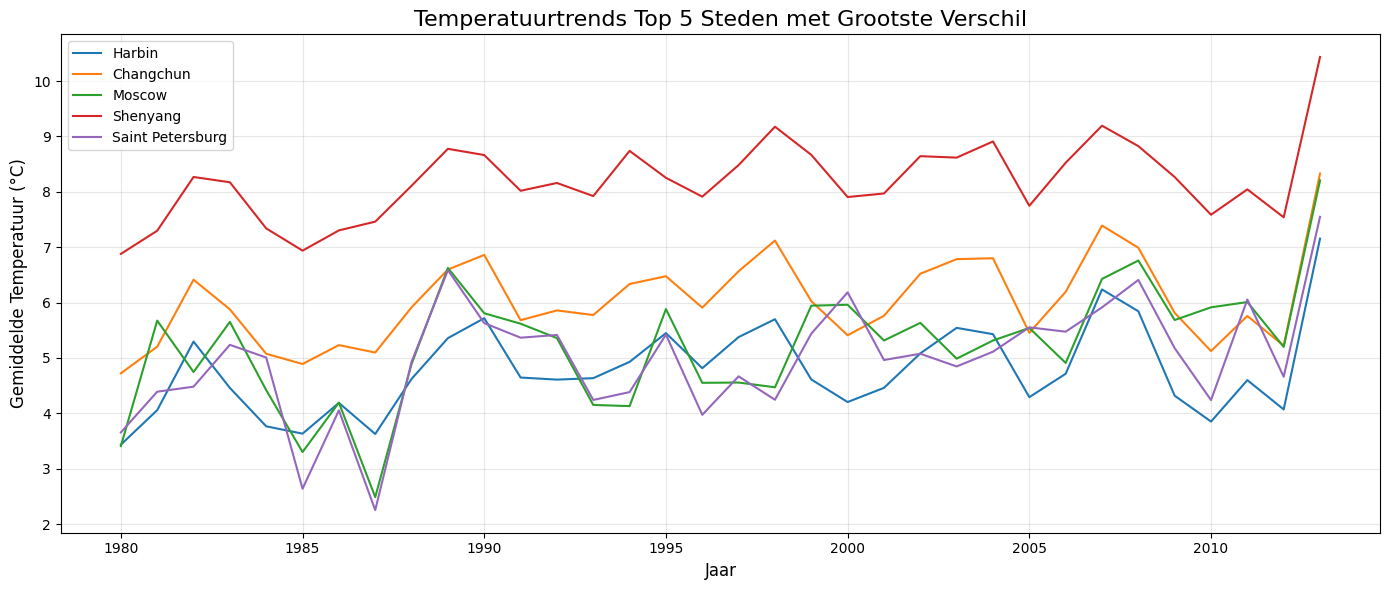

In [40]:
# === VISUALISATIE: TEMPERATUURTRENDS PER STAD ===

# Pak de top 5 steden met grootste verschil
top5_steden = top10_verschil.nlargest(5).index

# Jaar kolom aanmaken
df_major_city["jaar"] = df_major_city["dt"].dt.year

fig, ax = plt.subplots(figsize=(14, 6))

# Voor elke stad een lijn tekenen
for stad in top5_steden:
    stad_data = df_major_city[df_major_city["City"] == stad]
    per_jaar = stad_data.groupby("jaar")["AverageTemperature"].mean()
    ax.plot(per_jaar.index, per_jaar.values, label=stad, linewidth=1.5)

ax.set_title("Temperatuurtrends Top 5 Steden met Grootste Verschil", fontsize=16)
ax.set_xlabel("Jaar", fontsize=12)
ax.set_ylabel("Gemiddelde Temperatuur (°C)", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Opdracht 4.3 - Uncertainty Analysis
In dit deel analyseren we de onzekerheid in de metingen.


In [41]:
# === STAP 7.1: UNCERTAINTY ANALYSE ===

# Jaar kolom aanmaken
df_global["jaar"] = df_global["dt"].dt.year

# Gemiddelde uncertainty per jaar
uncertainty_per_jaar = df_global.groupby("jaar")["LandAverageTemperatureUncertainty"].mean()

print("Hoogste uncertainty jaren:")
print(uncertainty_per_jaar.nlargest(10))

print("\nLaagste uncertainty jaren:")
print(uncertainty_per_jaar.nsmallest(10))

Hoogste uncertainty jaren:
jaar
1980    0.106667
1984    0.102583
2013    0.097667
1983    0.094000
1985    0.093250
2015    0.092167
2003    0.090667
2014    0.090167
2006    0.090000
2007    0.089500
Name: LandAverageTemperatureUncertainty, dtype: float64

Laagste uncertainty jaren:
jaar
1991    0.062083
1994    0.070917
2002    0.072417
1998    0.073917
2005    0.075167
1995    0.076417
2008    0.078917
1999    0.079250
1988    0.080083
1993    0.081333
Name: LandAverageTemperatureUncertainty, dtype: float64


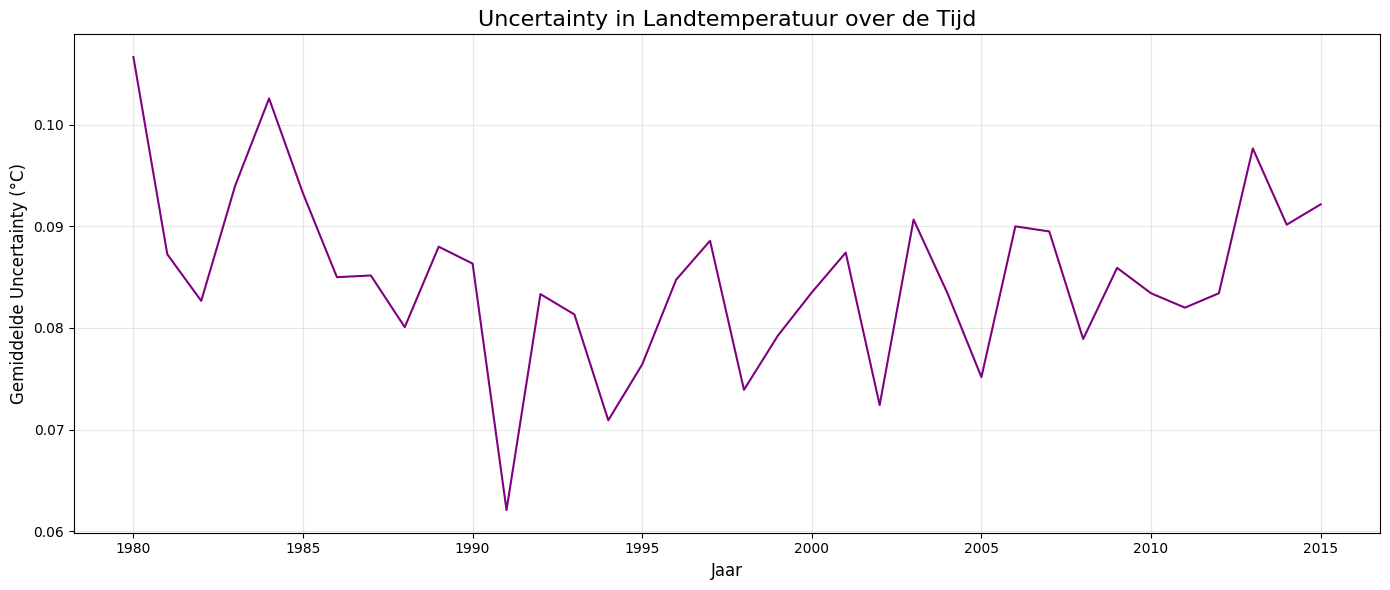

In [42]:
# === STAP 7.2: UNCERTAINTY OVER DE TIJD ===

plt.figure(figsize=(14, 6))

plt.plot(uncertainty_per_jaar.index, uncertainty_per_jaar.values, 
         color="purple", linewidth=1.5)

plt.title("Uncertainty in Landtemperatuur over de Tijd", fontsize=16)
plt.xlabel("Jaar", fontsize=12)
plt.ylabel("Gemiddelde Uncertainty (°C)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

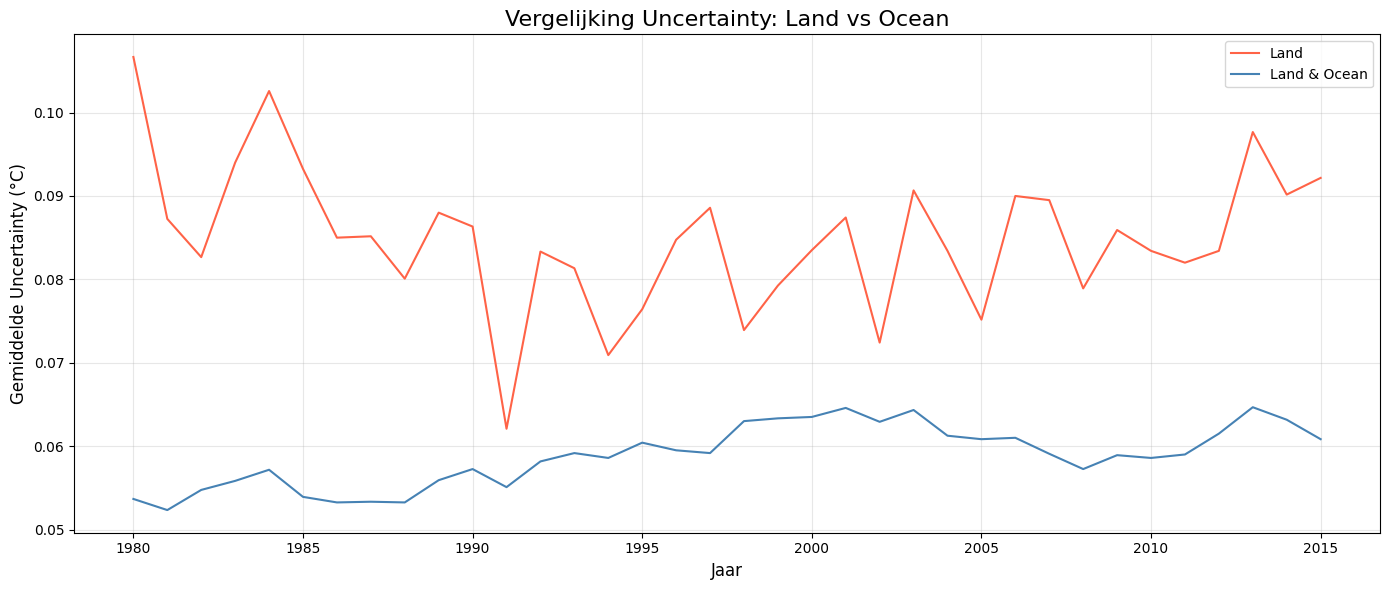

In [43]:
# === STAP 7.3: LAND VS OCEAN UNCERTAINTY ===

land_uncertainty = df_global.groupby("jaar")["LandAverageTemperatureUncertainty"].mean()
ocean_uncertainty = df_global.groupby("jaar")["LandAndOceanAverageTemperatureUncertainty"].mean()

plt.figure(figsize=(14, 6))

plt.plot(land_uncertainty.index, land_uncertainty.values, 
         color="tomato", linewidth=1.5, label="Land")
plt.plot(ocean_uncertainty.index, ocean_uncertainty.values, 
         color="steelblue", linewidth=1.5, label="Land & Ocean")

plt.title("Vergelijking Uncertainty: Land vs Ocean", fontsize=16)
plt.xlabel("Jaar", fontsize=12)
plt.ylabel("Gemiddelde Uncertainty (°C)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4.4 Geospatial analysis 
In dit deel visualiseren we temperatuurdata op een wereldkaart.

In [44]:
# === Stap 8.1 Choropleth kaart ===

#Gemiddelde temperatuur per land
gem_per_land = df_country.groupby("Country")["AverageTemperature"].mean().reset_index()

# Choropleth kaart maken met Plotly Express
fig = px.choropleth(gem_per_land, locations="Country", locationmode="country names",
                    color="AverageTemperature", color_continuous_scale="RdYlBu_r",
                    title="Gemiddelde Temperatuur per Land (°C) (1980-2015)", 
                    labels={"AverageTemperature": "Gemiddelde Temperatuur (°C)"}
)

fig.show()


C:\Users\Nesta\AppData\Local\Temp\ipykernel_30480\2817120645.py:7: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(gem_per_land, locations="Country", locationmode="country names",


In [45]:
# === Stap 8.2: Scatter geo kaart voor Major Cities ===

# Latitude en Longitude omzetten naar numeriek
def convert_lat(lat):
    if isinstance(lat, float):  
        return lat
    if "S" in lat:
        return -float(lat.replace("S", ""))
    else:
        return float(lat.replace("N", ""))

def convert_lon(lon):
    if isinstance(lon, float): 
        return lon
    if "W" in lon:
        return -float(lon.replace("W", ""))
    else:
        return float(lon.replace("E", ""))
    
df_major_city["Latitude"] = df_major_city["Latitude"].apply(convert_lat)
df_major_city["Longitude"] = df_major_city["Longitude"].apply(convert_lon)

print("Latitude en Longitude omgezet naar numeriek ✓")

# Gemiddelde temperatuur per stad
gem_per_grote_stad = df_major_city.groupby(["City", "Latitude", "Longitude"])["AverageTemperature"].mean().reset_index()

# Scatter geo kaart maken met Plotly Express
fig = px.scatter_geo(gem_per_grote_stad, lat="Latitude", lon="Longitude", 
                     color="AverageTemperature", size="AverageTemperature",
                     hover_name="City",
                     color_continuous_scale="RdYlBu_r",
                     size_max=10,
                     title="Gemiddelde Temperatuur per Grote Stad (°C) (1980-2015)",
                     labels={"AverageTemperature": "Gemiddelde Temperatuur (°C)"}
)

fig.show()

Latitude en Longitude omgezet naar numeriek ✓


In [46]:
# === Stap 8.3 Scatter geo kaart voor City's ===

# Latitude en Lonitude omzetten naar numeriek
def convert_lat(lat):
    if isinstance(lat, float):
        return lat
    if "S" in lat:
        return -float(lat.replace("S", ""))
    else:
        return float(lat.replace("N", ""))

def convert_lon(lon):
    if isinstance(lon, float):
        return lon
    if "W" in lon:
        return -float(lon.replace("W", ""))
    else:
        return float(lon.replace("E", ""))

df_city["Latitude"] = df_city["Latitude"].apply(convert_lat)
df_city["Longitude"] = df_city["Longitude"].apply(convert_lon)

print("Latitude en Longitude omgezet naar numeriek ✓")

# Gemiddelde temperatuur per stad
gem_per_stad = df_city.groupby(["City", "Latitude", "Longitude"])["AverageTemperature"].mean().reset_index()

# Scatter geo kaart maken met Plotly Express
fig = px.scatter_geo(gem_per_stad, lat="Latitude", lon="Longitude",
                     color="AverageTemperature",
                      hover_name="City",
                       color_continuous_scale="RdYlBu_r",
                        title="Gemiddelde Temperatuur per Stad (°C) (1980-2015)",
                         labels={"AverageTemperature": "Gemiddelde Temperatuur (°C)"}
)

fig.show()



Latitude en Longitude omgezet naar numeriek ✓


# Opdracht 5 - Power BI


In [47]:
# === Export naar CSV voor Power BI met puntkomma ===

# Afronden op 3 decimalen
df_global = df_global.round(3)
df_country = df_country.round(3)
df_state = df_state.round(3)
df_major_city = df_major_city.round(3)
df_city = df_city.round(3)

# Exporteer opnieuw
df_global.to_csv("PowerBI/Cleaned_GlobalTemperatures.csv", index=False, sep=";")
df_country.to_csv("PowerBI/Cleaned_TemperaturesByCountry.csv", index=False, sep=";")
df_state.to_csv("PowerBI/Cleaned_TemperaturesByState.csv", index=False, sep=";")
df_major_city.to_csv("PowerBI/Cleaned_TemperaturesByMajorCity.csv", index=False, sep=";")
df_city.to_csv("PowerBI/Cleaned_TemperaturesByCity.csv", index=False, sep=";")

print("Alle bestanden geëxporteerd ✓")

C:\Users\Nesta\AppData\Local\Temp\ipykernel_30480\240390522.py:4: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df_global = df_global.round(3)
C:\Users\Nesta\AppData\Local\Temp\ipykernel_30480\240390522.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df_country = df_country.round(3)
C:\Users\Nesta\AppData\Local\Temp\ipykernel_30480\240390522.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df_state = df_state.round(3)
C:\Users\Nesta\AppData\Local\Temp\ipykernel_30480\240390522.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df_major_city = df_major_city.round(3)
C:\Users\Nesta\AppData\Local\Temp\ipykernel_30480\240390522.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. U

OSError: Cannot save file into a non-existent directory: 'PowerBI'

In [ ]:
# === Top 10 steden met grootste temperatuurverschil ===

verschil_per_stad = df_major_city.groupby("City")["AverageTemperature"].agg(
    lambda x: round(x.max() - x.min(), 3)
).reset_index()

verschil_per_stad.columns = ["City", "TempVerschil"]
verschil_per_stad = verschil_per_stad.nlargest(10, "TempVerschil")

verschil_per_stad.to_csv("PowerBI/Top10_CityTempVerschil.csv", index=False, sep=";")
print("Top 10 steden geëxporteerd ✓")
print(verschil_per_stad)

Top 10 steden geëxporteerd ✓
                City  TempVerschil
34            Harbin        48.852
19         Changchun        46.542
65            Moscow        43.450
85          Shenyang        40.842
79  Saint Petersburg        40.510
64          Montreal        40.174
48              Kiev        39.868
96           Toronto        36.007
60           Mashhad        35.610
92           Taiyuan        35.450


In [ ]:
# === Volledige Global Temperatures voor Power BI ===

# Inladen uit MySQL
df_global_full = pd.read_sql("SELECT * FROM global_temperatures", engine)

# Cleaning toepassen via dezelfde functie (respecteert de 1850-regel)
df_global_full = clean_dataframe(df_global_full, fillna=True)

# Forceer numeriek datatype voor Ocean kolommen
ocean_cols = [k for k in df_global_full.columns if 'Ocean' in k]
for kolom in ocean_cols:
    df_global_full[kolom] = pd.to_numeric(df_global_full[kolom], errors='coerce')

# Zorg dat lege waarden echt leeg zijn in de CSV
df_global_full = df_global_full.where(pd.notnull(df_global_full), None)

# Exporteren
df_global_full.to_csv("PowerBI/Full_GlobalTemperatures.csv", index=False, sep=";")
print(f"Geëxporteerd ✓ ({len(df_global_full)} rijen)")

Geëxporteerd ✓ (3192 rijen)


C:\Users\Nesta\AppData\Local\Temp\ipykernel_21932\2275454090.py:32: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df = df.round(3)


# Opdracht 6

Zie klimaat_rapportage.md


# Bonus opdracht 

Ga online op zoek naar dataset over de volgende zaken en vergelijk deze met de temperatuurstijgingen die je hebt gevonden.

- CO2 uitstoot per land
- Ontbossing per land
- Bevolkingsgroei per land
- Industriële productie per land
- Energieverbruik per land
- Energiebronnen per land (fossiel, hernieuwbaar, etc)
- Armoede index per land
- Economische groei per land (BBP)

### CO2 vs. temperatuur per land


In [48]:
# Inladen CO2 dataset
df_co2 = pd.read_csv("../BonusData/CO2_country.csv")
print(df_co2.head())
print(df_co2.shape)
print(df_co2.columns)

        entity code  year  emissions_total
0  Afghanistan  AFG  1949          14656.0
1  Afghanistan  AFG  1950          84272.0
2  Afghanistan  AFG  1951          91600.0
3  Afghanistan  AFG  1952          91600.0
4  Afghanistan  AFG  1953         106256.0
(29384, 4)
Index(['entity', 'code', 'year', 'emissions_total'], dtype='str')


In [49]:
# Jaar kolom aanmaken in temperatuurdata
df_country["jaar"] = pd.to_datetime(df_country["dt"]).dt.year

# Gemiddelde temperatuur per land per jaar
temp_per_land = df_country.groupby(["Country", "jaar"])["AverageTemperature"].mean().reset_index()

# CO2 data filteren vanaf 1980
df_co2_1980 = df_co2[df_co2["year"] >= 1980]

# Samenvoegen op land en jaar
df_merged = pd.merge(
    temp_per_land,
    df_co2_1980,
    left_on=["Country", "jaar"],
    right_on=["entity", "year"],
    how="inner"
)

print(df_merged.head())
print(f"Aantal rijen na merge: {len(df_merged)}")

       Country  jaar  AverageTemperature       entity code  year  \
0  Afghanistan  1980           14.887333  Afghanistan  AFG  1980   
1  Afghanistan  1981           14.860083  Afghanistan  AFG  1981   
2  Afghanistan  1982           13.733083  Afghanistan  AFG  1982   
3  Afghanistan  1983           14.614833  Afghanistan  AFG  1983   
4  Afghanistan  1984           14.245833  Afghanistan  AFG  1984   

   emissions_total  
0        1756302.0  
1        1978463.0  
2        2094580.9  
3        2519954.0  
4        2821540.0  
Aantal rijen na merge: 6320


In [95]:
df_co2_temp = df_co2_temp[~df_co2_temp["Country"].isin(continenten)]
fig = px.scatter(
    df_co2_temp,
    x="emissions_total",
    y="temp_verandering",
    color="Country",
    hover_name="Country",
    title="CO2 uitstoot vs Temperatuurverandering per Land (1980-2013)",
    labels={
        "emissions_total": "Gemiddelde CO2 uitstoot (ton)",
        "temp_verandering": "Temperatuurverandering (°C)"
    },
    log_x=True
)
fig.show()

In [57]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Filter op Nederland
df_nl = df_merged_clean[df_merged_clean["Country"] == "Netherlands"]

# Maak grafiek met twee y-assen
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Temperatuur lijn
fig.add_trace(
    go.Scatter(x=df_nl["jaar"], y=df_nl["AverageTemperature"], name="Temperatuur (°C)", line=dict(color="red")),
    secondary_y=False
)

# CO2 lijn
fig.add_trace(
    go.Scatter(x=df_nl["jaar"], y=df_nl["emissions_total"], name="CO2 uitstoot (ton)", line=dict(color="blue")),
    secondary_y=True
)

fig.update_layout(title="Nederland - Temperatuur vs CO2 uitstoot (1980-2015)")
fig.update_yaxes(title_text="Temperatuur (°C)", secondary_y=False)
fig.update_yaxes(title_text="CO2 uitstoot (ton)", secondary_y=True)

fig.show()

### Ontbossing vs. temperatuur per land


In [62]:
df_forest = pd.read_csv("../BonusData/forest-area.csv")
print(df_forest.head())
print(df_forest.shape)
print(df_forest.columns)

        Entity Code  Year  Annual change in forest area
0  Afghanistan  AFG  1991                           0.0
1  Afghanistan  AFG  1992                           0.0
2  Afghanistan  AFG  1993                           0.0
3  Afghanistan  AFG  1994                           0.0
4  Afghanistan  AFG  1995                           0.0
(8680, 4)
Index(['Entity', 'Code', 'Year', 'Annual change in forest area'], dtype='str')


In [63]:
# Filter vanaf 1980
df_forest_1980 = df_forest[df_forest["Year"] >= 1980]

# Samenvoegen met temperatuurdata
df_merged_forest = pd.merge(
    temp_per_land,
    df_forest_1980,
    left_on=["Country", "jaar"],
    right_on=["Entity", "Year"],
    how="inner"
)

print(df_merged_forest.head())
print(f"Aantal rijen na merge: {len(df_merged_forest)}")

       Country  jaar  AverageTemperature       Entity Code  Year  \
0  Afghanistan  1991           14.370750  Afghanistan  AFG  1991   
1  Afghanistan  1992           14.056083  Afghanistan  AFG  1992   
2  Afghanistan  1993           14.439250  Afghanistan  AFG  1993   
3  Afghanistan  1994           14.754750  Afghanistan  AFG  1994   
4  Afghanistan  1995           14.859167  Afghanistan  AFG  1995   

   Annual change in forest area  
0                           0.0  
1                           0.0  
2                           0.0  
3                           0.0  
4                           0.0  
Aantal rijen na merge: 4577


In [96]:
# Ontbossing vs Temperatuurverandering
df_forest_temp = pd.merge(
    temp_verschil,
    df_forest_1980.groupby("Entity")["Annual change in forest area"].mean().reset_index(),
    left_on="Country",
    right_on="Entity",
    how="inner"
)

# Verwijder continenten
df_forest_temp = df_forest_temp[~df_forest_temp["Country"].isin(continenten)]

fig = px.scatter(
    df_forest_temp,
    x="Annual change in forest area",
    y="temp_verandering",
    color="Country",
    hover_name="Country",
    title="Ontbossing vs Temperatuurverandering per Land (1980-2013)",
    labels={
        "Annual change in forest area": "Jaarlijkse verandering bosoppervlak (km²)",
        "temp_verandering": "Temperatuurverandering (°C)"
    }
)

fig.show()

### Populatie groei vs. Temperatuur


In [66]:
df_population = pd.read_csv("../BonusData/population-growth.csv")
print(df_population.head())
print(df_population.shape)
print(df_population.columns)

        Entity Code  Year  Population  Population (Projected)
0  Afghanistan  AFG  1950   7776180.0                     NaN
1  Afghanistan  AFG  1951   7879343.0                     NaN
2  Afghanistan  AFG  1952   7987784.0                     NaN
3  Afghanistan  AFG  1953   8096703.0                     NaN
4  Afghanistan  AFG  1954   8207954.0                     NaN
(39562, 5)
Index(['Entity', 'Code', 'Year', 'Population', 'Population (Projected)'], dtype='str')


In [67]:
# Filter vanaf 1980
df_population_1980 = df_population[df_population["Year"] >= 1980]

# Samenvoegen met temperatuurdata
df_merged_population = pd.merge(
    temp_per_land,
    df_population_1980,
    left_on=["Country", "jaar"],
    right_on=["Entity", "Year"],
    how="inner"
)

print(df_merged_population.head())
print(f"Aantal rijen na merge: {len(df_merged_population)}")

       Country  jaar  AverageTemperature       Entity Code  Year  Population  \
0  Afghanistan  1980           14.887333  Afghanistan  AFG  1980  13169313.0   
1  Afghanistan  1981           14.860083  Afghanistan  AFG  1981  11937586.0   
2  Afghanistan  1982           13.733083  Afghanistan  AFG  1982  10991380.0   
3  Afghanistan  1983           14.614833  Afghanistan  AFG  1983  10917985.0   
4  Afghanistan  1984           14.245833  Afghanistan  AFG  1984  11190222.0   

   Population (Projected)  
0                     NaN  
1                     NaN  
2                     NaN  
3                     NaN  
4                     NaN  
Aantal rijen na merge: 6834


In [98]:
# Bevolking in 1980 en 2013
pop_begin = df_population_1980[df_population_1980["Year"] == 1980][["Entity", "Population"]].rename(columns={"Population": "pop_1980"})
pop_eind = df_population_1980[df_population_1980["Year"] == 2013][["Entity", "Population"]].rename(columns={"Population": "pop_2013"})

# Bereken groei percentage
pop_verschil = pd.merge(pop_begin, pop_eind, on="Entity")
pop_verschil["pop_groei_pct"] = ((pop_verschil["pop_2013"] - pop_verschil["pop_1980"]) / pop_verschil["pop_1980"]) * 100

# Merge met temperatuurverandering
df_pop_temp = pd.merge(
    temp_verschil,
    pop_verschil,
    left_on="Country",
    right_on="Entity",
    how="inner"
)

# Verwijder continenten
df_pop_temp = df_pop_temp[~df_pop_temp["Country"].isin(continenten)]

fig = px.scatter(
    df_pop_temp,
    x="pop_groei_pct",
    y="temp_verandering",
    color="Country",
    hover_name="Country",
    title="Bevolkingsgroei vs Temperatuurverandering per Land (1980-2013)",
    labels={
        "pop_groei_pct": "Bevolkingsgroei (%)",
        "temp_verandering": "Temperatuurverandering (°C)"
    }
)

fig.show()

### Productie vs. temperatur


In [100]:
df_industry = pd.read_csv("../BonusData/gdp-industry.csv")
print(df_industry.head())
print(df_industry.shape)
print(df_industry.columns)

        Entity Code  Year  Share of industry in GDP at constant 2005 prices  \
0  Afghanistan  AFG  1950                                               NaN   
1  Afghanistan  AFG  1951                                               NaN   
2  Afghanistan  AFG  1952                                               NaN   
3  Afghanistan  AFG  1953                                               NaN   
4  Afghanistan  AFG  1954                                               NaN   

   GDP per capita  Population World region according to OWID  \
0          1156.0   7776180.0                           Asia   
1          1170.0   7879343.0                           Asia   
2          1189.0   7987784.0                           Asia   
3          1240.0   8096703.0                           Asia   
4          1245.0   8207954.0                           Asia   

  GDP per capita (Annotations)  
0                          NaN  
1                          NaN  
2                          NaN  
3       

In [101]:
# Filter vanaf 1980 en verwijder NaN's
df_industry_1980 = df_industry[df_industry["Year"] >= 1980].dropna(subset=["Share of industry in GDP at constant 2005 prices"])

# Gemiddeld industry share per land
industry_per_land = df_industry_1980.groupby("Entity")["Share of industry in GDP at constant 2005 prices"].mean().reset_index()

# Merge met temperatuurverandering
df_industry_temp = pd.merge(
    temp_verschil,
    industry_per_land,
    left_on="Country",
    right_on="Entity",
    how="inner"
)

# Verwijder continenten
df_industry_temp = df_industry_temp[~df_industry_temp["Country"].isin(continenten)]

# Scatterplot
fig = px.scatter(
    df_industry_temp,
    x="Share of industry in GDP at constant 2005 prices",
    y="temp_verandering",
    color="Country",
    hover_name="Country",
    title="Industrieel aandeel GDP vs Temperatuurverandering per Land (1980-2013)",
    labels={
        "Share of industry in GDP at constant 2005 prices": "Industrie aandeel GDP (%)",
        "temp_verandering": "Temperatuurverandering (°C)"
    }
)

fig.show()

### Energieverbruik vs. temperatuur per land

In [72]:
df_energy = pd.read_csv("../BonusData/energy_consumption.csv")
print(df_energy.head())
print(df_energy.shape)
print(df_energy.columns)

   Entity      Code  Year  Other renewables  Biofuels  Solar  Wind  \
0  Africa  OWID_AFR  1965               0.0       0.0    0.0   0.0   
1  Africa  OWID_AFR  1966               0.0       0.0    0.0   0.0   
2  Africa  OWID_AFR  1967               0.0       0.0    0.0   0.0   
3  Africa  OWID_AFR  1968               0.0       0.0    0.0   0.0   
4  Africa  OWID_AFR  1969               0.0       0.0    0.0   0.0   

   Hydropower  Nuclear        Gas       Coal        Oil  
0   38.626762      0.0   9.571930  323.49615  341.07257  
1   43.083344      0.0  10.698092  323.12222  369.46457  
2   44.973988      0.0  10.573844  330.29160  368.28156  
3   52.606503      0.0  10.717145  343.51288  389.57162  
4   61.391357      0.0  12.520175  346.64288  397.37260  
(8317, 12)
Index(['Entity', 'Code', 'Year', 'Other renewables', 'Biofuels', 'Solar',
       'Wind', 'Hydropower', 'Nuclear', 'Gas', 'Coal', 'Oil'],
      dtype='str')


In [73]:
# Bereken totaal energieverbruik per land per jaar
df_energy["total_energy"] = df_energy[["Other renewables", "Biofuels", "Solar", "Wind", "Hydropower", "Nuclear", "Gas", "Coal", "Oil"]].sum(axis=1)

# Filter vanaf 1980
df_energy_1980 = df_energy[df_energy["Year"] >= 1980]

# Samenvoegen met temperatuurdata
df_merged_energy = pd.merge(
    temp_per_land,
    df_energy_1980,
    left_on=["Country", "jaar"],
    right_on=["Entity", "Year"],
    how="inner"
)

# Verwijder continenten
df_energy_clean = df_merged_energy[~df_merged_energy["Country"].isin(continenten)]

print(df_energy_clean.head())
print(f"Aantal rijen na merge: {len(df_energy_clean)}")

    Country  jaar  AverageTemperature   Entity Code  Year  Other renewables  \
34  Algeria  1980           23.160167  Algeria  DZA  1980               0.0   
35  Algeria  1981           23.579250  Algeria  DZA  1981               0.0   
36  Algeria  1982           23.094167  Algeria  DZA  1982               0.0   
37  Algeria  1983           23.683000  Algeria  DZA  1983               0.0   
38  Algeria  1984           23.063083  Algeria  DZA  1984               0.0   

    Biofuels  Solar  Wind  Hydropower  Nuclear        Gas      Coal  \
34       0.0    0.0   0.0    0.713889      0.0  109.43625  0.744320   
35       0.0    0.0   0.0    1.016667      0.0  142.25749  0.523350   
36       0.0    0.0   0.0    1.330556      0.0  161.41125  9.711049   
37       0.0    0.0   0.0    0.652778      0.0  176.71501  8.664350   
38       0.0    0.0   0.0    1.255556      0.0  155.25125  9.606380   

          Oil  total_energy  
34  66.202430    177.096889  
35  71.323074    215.120581  
36  75.5

In [82]:
# Gebruik 2013 als eindjaar in plaats van 2015
temp_begin = temp_per_land[temp_per_land["jaar"] == 1980][["Country", "AverageTemperature"]].rename(columns={"AverageTemperature": "temp_1980"})
temp_eind = temp_per_land[temp_per_land["jaar"] == 2013][["Country", "AverageTemperature"]].rename(columns={"AverageTemperature": "temp_2013"})

temp_verschil = pd.merge(temp_begin, temp_eind, on="Country")
temp_verschil["temp_verandering"] = temp_verschil["temp_2013"] - temp_verschil["temp_1980"]

print(f"Aantal landen: {len(temp_verschil)}")
print(temp_verschil.sort_values("temp_verandering", ascending=False).head(10))

Aantal landen: 243
                    Country  temp_1980  temp_2013  temp_verandering
88                Greenland -17.515417 -11.559333          5.956083
58                  Denmark -17.009250 -11.130444          5.878806
180                  Russia  -5.420750   0.126556          5.547306
210  Svalbard And Jan Mayen  -7.994167  -2.645778          5.348389
144                Mongolia  -0.482667   4.634000          5.116667
228                 Ukraine   6.900083  11.839111          4.939028
75                  Finland   0.881667   5.750778          4.869111
142                 Moldova   8.129750  12.769778          4.640028
22                  Belarus   4.997167   9.486222          4.489056
179                 Romania   8.076917  12.489778          4.412861


In [85]:
fig = px.scatter(
    df_energie_temp,
    x="pct_hernieuwbaar",
    y="temp_verandering",
    color="Country",
    hover_name="Country",
    title="Aandeel Hernieuwbare Energie vs Temperatuurverandering per Land (1980-2013)",
    labels={
        "pct_hernieuwbaar": "Gemiddeld Aandeel Hernieuwbaar (%)",
        "temp_verandering": "Temperatuurverandering (°C)"
    }
)

fig.show()

### Armoede vs. temperatuurstijging per land

In [86]:
df_poverty = pd.read_csv("../BonusData/poverty.csv")
print(df_poverty.head())
print(df_poverty.shape)
print(df_poverty.columns)

        Entity Code   Year  Share of population in poverty ($3 a day)  \
0  Afghanistan  AFG -10000                                        NaN   
1  Afghanistan  AFG  -9000                                        NaN   
2  Afghanistan  AFG  -8000                                        NaN   
3  Afghanistan  AFG  -7000                                        NaN   
4  Afghanistan  AFG  -6000                                        NaN   

   Population World region according to OWID  
0     14737.0                           Asia  
1     20405.0                           Asia  
2     28253.0                           Asia  
3     39120.0                           Asia  
4     54166.0                           Asia  
(59371, 6)
Index(['Entity', 'Code', 'Year', 'Share of population in poverty ($3 a day)',
       'Population', 'World region according to OWID'],
      dtype='str')


In [87]:
# Filter vanaf 1980
df_poverty_1980 = df_poverty[df_poverty["Year"] >= 1980]
print(f"Aantal rijen vanaf 1980: {len(df_poverty_1980)}")

# Hoeveel NaN's?
print(f"NaN's in armoede kolom: {df_poverty_1980['Share of population in poverty ($3 a day)'].isna().sum()}")

# Welke jaren hebben data?
print(df_poverty_1980[df_poverty_1980["Share of population in poverty ($3 a day)"].notna()]["Year"].unique())

Aantal rijen vanaf 1980: 11992
NaN's in armoede kolom: 9204
[1996 2002 2005 2008 2012 2014 2015 2016 2017 2018 2019 2020 1988 1995
 2011 2000 1980 1986 1987 1991 1992 1993 1994 1997 1998 1999 2001 2003
 2004 2006 2007 2009 2010 2013 2021 2022 2023 2024 1981 1985 1989 1983
 1990 1982 1984 2025 2026]


In [88]:
# Verwijder NaN's
df_poverty_clean = df_poverty_1980.dropna(subset=["Share of population in poverty ($3 a day)"])

# Gemiddeld armoede percentage per land
poverty_per_land = df_poverty_clean.groupby("Entity")["Share of population in poverty ($3 a day)"].mean().reset_index()

# Merge met temperatuurverandering
df_poverty_temp = pd.merge(
    temp_verschil,
    poverty_per_land,
    left_on="Country",
    right_on="Entity",
    how="inner"
)

print(f"Aantal landen na merge: {len(df_poverty_temp)}")
print(df_poverty_temp.head())

Aantal landen na merge: 151
     Country  temp_1980  temp_2013  temp_verandering     Entity  \
0    Albania  12.162083  15.466111          3.304028    Albania   
1    Algeria  23.160167  24.468444          1.308278    Algeria   
2     Angola  22.077583  22.145222          0.067639     Angola   
3    Armenia   9.358583  12.221556          2.862972    Armenia   
4  Australia  22.586167  21.820778         -0.765389  Australia   

   Share of population in poverty ($3 a day)  
0                                   1.786172  
1                                   8.023333  
2                                  29.442975  
3                                   5.838564  
4                                   0.792308  


In [89]:
fig = px.scatter(
    df_poverty_temp,
    x="Share of population in poverty ($3 a day)",
    y="temp_verandering",
    color="Country",
    hover_name="Country",
    title="Armoede vs Temperatuurverandering per Land (1980-2013)",
    labels={
        "Share of population in poverty ($3 a day)": "Aandeel bevolking in armoede (%)",
        "temp_verandering": "Temperatuurverandering (°C)"
    }
)

fig.show()

In [90]:
# Gemiddelde absolute temperatuur per land over hele periode
temp_gemiddeld = temp_per_land.groupby("Country")["AverageTemperature"].mean().reset_index()

# Merge met armoede data
df_poverty_abs = pd.merge(
    temp_gemiddeld,
    poverty_per_land,
    left_on="Country",
    right_on="Entity",
    how="inner"
)

# Scatterplot met absolute temperatuur
fig = px.scatter(
    df_poverty_abs,
    x="Share of population in poverty ($3 a day)",
    y="AverageTemperature",
    color="Country",
    hover_name="Country",
    title="Armoede vs Gemiddelde Temperatuur per Land (1980-2013)",
    labels={
        "Share of population in poverty ($3 a day)": "Aandeel bevolking in armoede (%)",
        "AverageTemperature": "Gemiddelde Temperatuur (°C)"
    }
)

fig.show()

### Economische groei per land (BBP) vs Temperatuurstijging per land

In [91]:
df_gdp = pd.read_csv("../BonusData/gdp.csv")
print(df_gdp.head())
print(df_gdp.shape)
print(df_gdp.columns)

        Entity Code  Year  GDP per capita World region according to OWID
0  Afghanistan  AFG  2000       1617.8264                           Asia
1  Afghanistan  AFG  2001       1454.1108                           Asia
2  Afghanistan  AFG  2002       1774.3087                           Asia
3  Afghanistan  AFG  2003       1815.9282                           Asia
4  Afghanistan  AFG  2004       1776.9182                           Asia
(7240, 5)
Index(['Entity', 'Code', 'Year', 'GDP per capita',
       'World region according to OWID'],
      dtype='str')


In [92]:
# Filter vanaf 1980
df_gdp_1980 = df_gdp[df_gdp["Year"] >= 1980]

# Gemiddeld GDP per land
gdp_per_land = df_gdp_1980.groupby("Entity")["GDP per capita"].mean().reset_index()

# Merge met temperatuurverandering
df_gdp_temp = pd.merge(
    temp_verschil,
    gdp_per_land,
    left_on="Country",
    right_on="Entity",
    how="inner"
)

print(f"Aantal landen na merge: {len(df_gdp_temp)}")

# Scatterplot
fig = px.scatter(
    df_gdp_temp,
    x="GDP per capita",
    y="temp_verandering",
    color="Country",
    hover_name="Country",
    title="GDP per capita vs Temperatuurverandering per Land (1980-2013)",
    labels={
        "GDP per capita": "GDP per capita (USD)",
        "temp_verandering": "Temperatuurverandering (°C)"
    },
    log_x=True
)

fig.show()

Aantal landen na merge: 170
